In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('./data/df_melt.csv')

# --- Data Cleaning and Preparation ---

In [3]:
# Convert 'value' to numeric, coercing errors (handles empty strings '')
df['value'] = pd.to_numeric(df['value'], errors='coerce')

In [4]:
# Convert 'value' to numeric, coercing errors (handles empty strings '')
df['value'] = pd.to_numeric(df['value'], errors='coerce')

In [5]:
# Drop rows with missing 'value' (these are future/incomplete data points)
df.dropna(subset=['value'], inplace=True)

In [6]:
# Convert 'value' to integer
df['value'] = df['value'].astype(int)

In [7]:
# Convert year and month to datetime objects for easier plotting/analysis
df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))

# --- Aggregate Fuel Types ---

In [8]:
def aggregate_fuel_type_specific(fuel_type):
    fuel_type_upper = str(fuel_type).upper()
    if fuel_type_upper in ['PETROL', 'PETROL/CNG', 'PETROL/HYBRID', 'PETROL/LPG', 'PETROL/ETHANOL', 'PETROL/METHANOL']:
        return 'Petrol'
    elif fuel_type_upper in ['DIESEL', 'DIESEL/HYBRID', 'DUAL DIESEL/CNG']:
        return 'Diesel'
    elif fuel_type_upper in ['ELECTRIC(BOV)', 'PURE EV', 'FUEL CELL HYDROGEN']:
        return 'Electric (EV)'
    elif fuel_type_upper in ['PLUG-IN HYBRID EV', 'STRONG HYBRID EV']:
        return 'Hybrid EV'
    elif fuel_type_upper in ['CNG ONLY', 'LPG ONLY']:
        return 'CNG/LPG'
    else:
        return 'Other/Unknown'

df['Aggregated_Category_Specific'] = df['Fuel_Type'].apply(aggregate_fuel_type_specific)

# --- Yearly Aggregation ---

In [9]:
df.head()

,year,month,Fuel_Type,value,fuel_category,date,Aggregated_Category_Specific
0,2002,1,CNG ONLY,47,CNG/LPG,2002-01-01,CNG/LPG
1,2002,1,DIESEL,21546,Diesel,2002-01-01,Diesel
2,2002,1,DIESEL/HYBRID,0,Diesel,2002-01-01,Diesel
3,2002,1,ELECTRIC(BOV),10,Electric (EV),2002-01-01,Electric (EV)
4,2002,1,LPG ONLY,30,CNG/LPG,2002-01-01,CNG/LPG


In [10]:
yearly_data_specific = df.groupby(['date', 'Aggregated_Category_Specific'])['value'].sum().unstack(fill_value=0)

# --- Combine EV and Hybrid ---

In [11]:

yearly_data_specific['Electrified (EV + Hybrid)'] = yearly_data_specific['Electric (EV)'] + yearly_data_specific['Hybrid EV']

In [12]:
yearly_data_specific.tail(6)

Aggregated_Category_Specific,CNG/LPG,Diesel,Electric (EV),Hybrid EV,Other/Unknown,Petrol,Electrified (EV + Hybrid)
date,,,,,,,
2024-11-01,29,133160,8714,6905,4961,232871,15619
2024-12-01,30,142097,8688,6989,4304,215572,15677
2025-01-01,45,162693,10802,9183,5021,346580,19985
2025-02-01,35,117704,8689,7264,3930,211118,15953
2025-03-01,35,128703,11971,8166,4355,239433,20137
2025-04-01,11,22391,2236,1802,867,54278,4038


In [13]:
# Calculate total registrations per year including the new combined category
yearly_totals_specific = yearly_data_specific.drop(columns=['Electric (EV)', 'Hybrid EV']).sum(axis=1) # Avoid double counting

# --- Calculate Market Share ---

In [14]:
# Recalculate share based on the new combined category and avoiding double counting
yearly_share_specific = yearly_data_specific.drop(columns=['Electric (EV)', 'Hybrid EV']).div(yearly_totals_specific, axis=0) * 100

In [15]:
# Calculate Year-over-Year Growth Rate for Electrified Vehicles
yearly_data_specific['Electrified_YoY_Growth (%)'] = yearly_data_specific['Electrified (EV + Hybrid)'].pct_change() * 100
yearly_share_specific['Electrified_Share_YoY_Change (pp)'] = yearly_share_specific['Electrified (EV + Hybrid)'].diff() # pp = percentage points

In [16]:
yearly_data_specific.tail(6)

Aggregated_Category_Specific,CNG/LPG,Diesel,Electric (EV),Hybrid EV,Other/Unknown,Petrol,Electrified (EV + Hybrid),Electrified_YoY_Growth (%)
date,,,,,,,,
2024-11-01,29,133160,8714,6905,4961,232871,15619,-22.922424
2024-12-01,30,142097,8688,6989,4304,215572,15677,0.371343
2025-01-01,45,162693,10802,9183,5021,346580,19985,27.479747
2025-02-01,35,117704,8689,7264,3930,211118,15953,-20.175131
2025-03-01,35,128703,11971,8166,4355,239433,20137,26.227042
2025-04-01,11,22391,2236,1802,867,54278,4038,-79.947361


In [17]:
yearly_share_specific.tail(6)

Aggregated_Category_Specific,CNG/LPG,Diesel,Other/Unknown,Petrol,Electrified (EV + Hybrid),Electrified_Share_YoY_Change (pp)
date,,,,,,
2024-11-01,0.007501,34.440306,1.283106,60.229412,4.039675,0.241141
2024-12-01,0.007943,37.623650,1.139589,57.077950,4.150868,0.111193
2025-01-01,0.008422,30.448380,0.939692,64.863266,3.740240,-0.410628
2025-02-01,0.010036,33.751219,1.126914,60.537363,4.574468,0.834228
2025-03-01,0.008913,32.776961,1.109094,60.976715,5.128316,0.553848
2025-04-01,0.013483,27.444996,1.062695,66.529387,4.949439,-0.178877


In [18]:
yearly_data_specific.to_csv('./data/yearly_data_specific.csv')
yearly_share_specific.to_csv('./data/yearly_share_specific.csv')
yearly_totals_specific.to_csv('./data/yearly_totals_specific.csv')


# --- Analyze EV Adoption Trends ---

In [19]:
print("--- Yearly Electrified (EV + Hybrid) Registrations and Growth ---")
# Display relevant columns including the combined one
print(yearly_data_specific[['Electric (EV)', 'Hybrid EV', 'Electrified (EV + Hybrid)', 'Electrified_YoY_Growth (%)']].round(1))

print("\n--- Yearly Electrified (EV + Hybrid) Market Share and Change ---")
# Display relevant share columns
print(yearly_share_specific[['Electrified (EV + Hybrid)', 'Electrified_Share_YoY_Change (pp)']].round(2))


--- Yearly Electrified (EV + Hybrid) Registrations and Growth ---
Aggregated_Category_Specific  Electric (EV)  Hybrid EV  \
date                                                     
2002-01-01                               10          0   
2002-02-01                                7          0   
2002-03-01                               23          0   
2002-04-01                                8          0   
2002-05-01                               19          0   
...                                     ...        ...   
2024-12-01                             8688       6989   
2025-01-01                            10802       9183   
2025-02-01                             8689       7264   
2025-03-01                            11971       8166   
2025-04-01                             2236       1802   

Aggregated_Category_Specific  Electrified (EV + Hybrid)  \
date                                                      
2002-01-01                                           10   
20

# --- Plotting Combined Electrified Trends ---

In [20]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

In [21]:
yearly_data_specific = yearly_data_specific[yearly_data_specific.index != 2025]

In [22]:
yearly_data_specific[yearly_data_specific.index > '2020']

Aggregated_Category_Specific,CNG/LPG,Diesel,Electric (EV),Hybrid EV,Other/Unknown,Petrol,Electrified (EV + Hybrid),Electrified_YoY_Growth (%)
date,,,,,,,,
2020-02-01,12,120602,105,0,5676,163215,105,23.529412
2020-03-01,41,116505,244,0,5469,155330,244,132.380952
2020-04-01,13,15029,2,0,427,14436,2,-99.180328
2020-05-01,0,14125,62,0,1751,28089,62,3000.000000
2020-06-01,2,68250,241,0,5226,114359,241,288.709677
...,...,...,...,...,...,...,...,...
2024-12-01,30,142097,8688,6989,4304,215572,15677,0.371343
2025-01-01,45,162693,10802,9183,5021,346580,19985,27.479747
2025-02-01,35,117704,8689,7264,3930,211118,15953,-20.175131


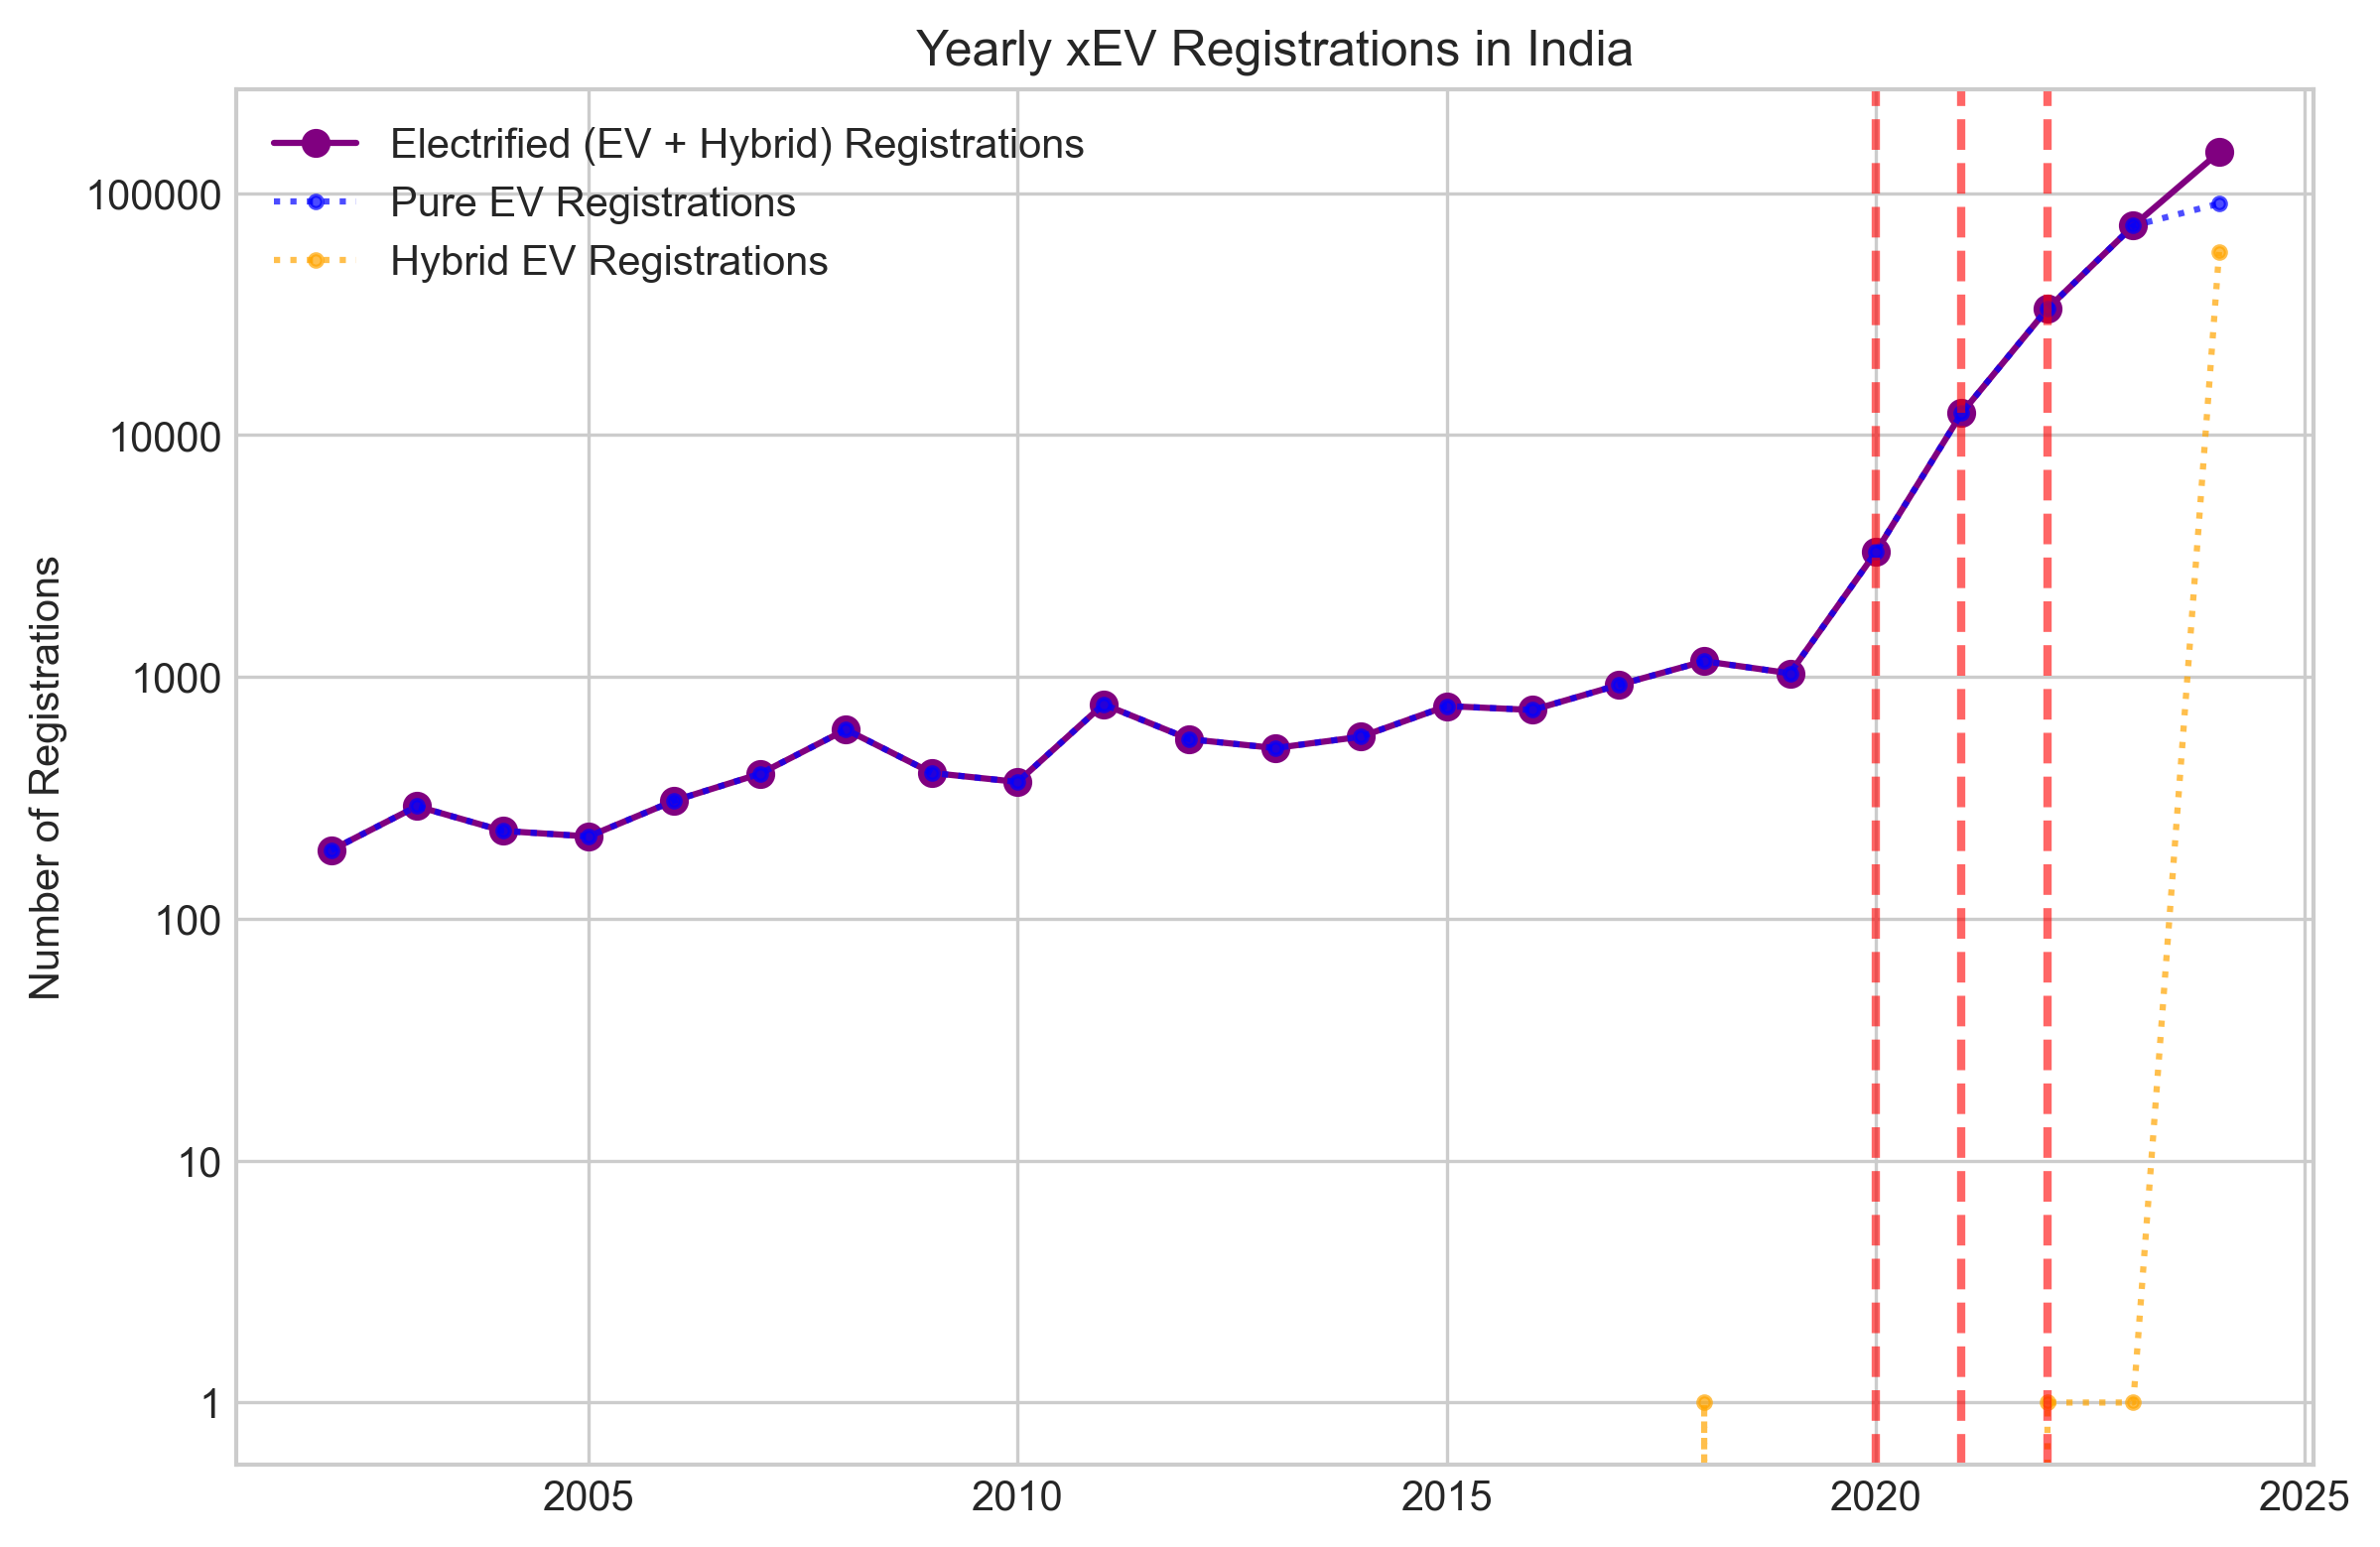

In [23]:
plt.style.use('seaborn-v0_8-whitegrid')
yearly_data_specific.index = pd.to_datetime(yearly_data_specific.index)
# Aggregate data to yearly totals (sum all values within each year)
filtered = yearly_data_specific[yearly_data_specific.index.year < 2025]
yearly_aggregated = filtered.groupby(filtered.index.year).sum()

fig_combined, axes_combined = plt.subplots(dpi=300, figsize=(9, 6), sharex=True)

# Plot 1: Absolute Electrified Registrations
axes_combined.plot(yearly_aggregated.index, yearly_aggregated['Electrified (EV + Hybrid)'], marker='o', linestyle='-', color='purple', label='Electrified (EV + Hybrid) Registrations')
# Optional: Plot individual EV and Hybrid lines for comparison
axes_combined.plot(yearly_aggregated.index, yearly_aggregated['Electric (EV)'], marker='.', linestyle=':', color='blue', alpha=0.7, label='Pure EV Registrations')
axes_combined.plot(yearly_aggregated.index, yearly_aggregated['Hybrid EV'], marker='.', linestyle=':', color='orange', alpha=0.7, label='Hybrid EV Registrations')

axes_combined.set_ylabel('Number of Registrations')
axes_combined.set_title('Yearly xEV Registrations in India')
axes_combined.legend()
axes_combined.grid(True)
axes_combined.set_yscale('log') # Use log scale due to rapid growth

axes_combined.yaxis.set_major_formatter(ScalarFormatter())
axes_combined.ticklabel_format(style='plain', axis='y') # Prevent scientific notation

# Highlight potential turning point years visually
turning_points_years = [2020, 2021, 2022]
for year in turning_points_years:
    if year in yearly_aggregated.index:
        axes_combined.axvline(x=year, color='red', linestyle='--', alpha=0.6, linewidth=2)

plt.show()

In [31]:
yearly_share_specific.tail(6)


Aggregated_Category_Specific,CNG/LPG,Diesel,Other/Unknown,Petrol,Electrified (EV + Hybrid),Electrified_Share_YoY_Change (pp)
date,,,,,,
2024-11-01,0.007501,34.440306,1.283106,60.229412,4.039675,0.241141
2024-12-01,0.007943,37.623650,1.139589,57.077950,4.150868,0.111193
2025-01-01,0.008422,30.448380,0.939692,64.863266,3.740240,-0.410628
2025-02-01,0.010036,33.751219,1.126914,60.537363,4.574468,0.834228
2025-03-01,0.008913,32.776961,1.109094,60.976715,5.128316,0.553848
2025-04-01,0.013483,27.444996,1.062695,66.529387,4.949439,-0.178877


In [37]:
yearly_data_specific.groupby(yearly_data_specific.index.year)["Electrified (EV + Hybrid)"].sum()

date
2002       192
2003       292
2004       231
2005       219
2006       308
2007       398
2008       606
2009       401
2010       368
2011       771
2012       553
2013       508
2014       566
2015       758
2016       730
2017       926
2018      1162
2019      1035
2020      3282
2021     12322
2022     33284
2023     73350
2024    147667
2025     60113
Name: Electrified (EV + Hybrid), dtype: int64

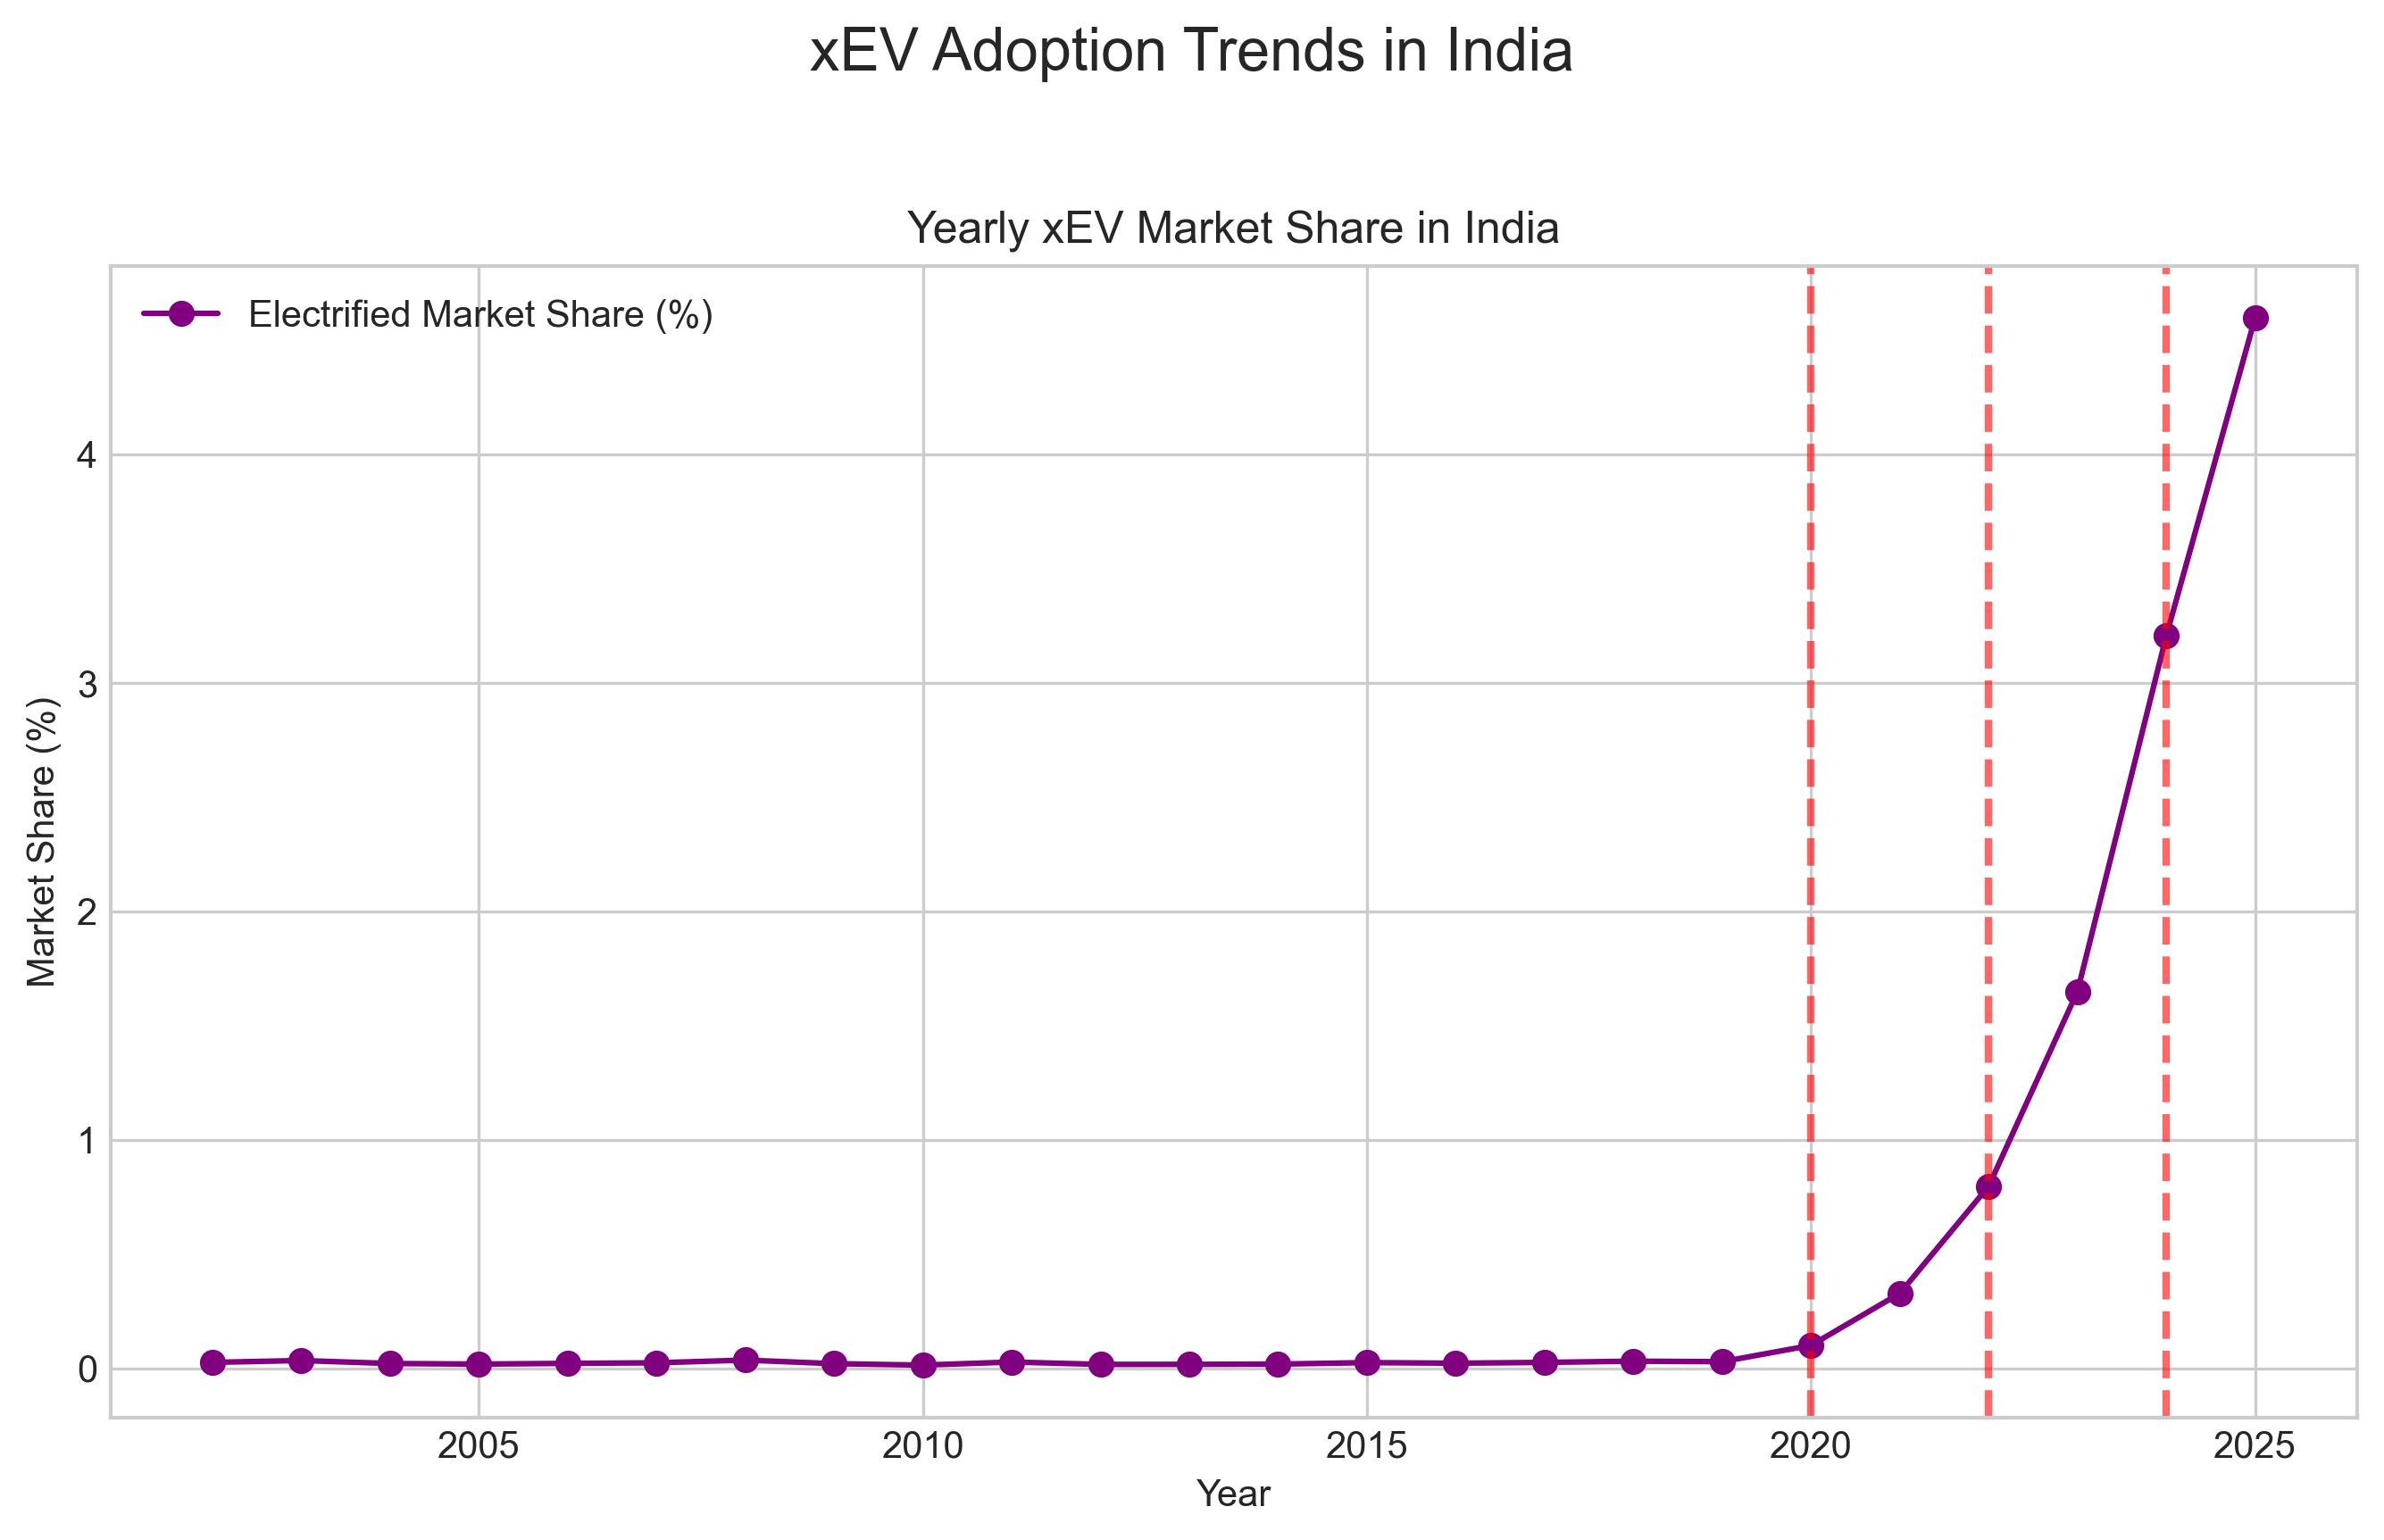

In [26]:
plt.style.use('seaborn-v0_8-whitegrid')

# Aggregate data to yearly totals
yearly_share_aggregated = yearly_share_specific.groupby(yearly_share_specific.index.year).mean()

fig_combined, axes_combined = plt.subplots(figsize=(9, 6),dpi=300, sharex=True)

# Plot 2: Electrified Market Share Percentage
axes_combined.plot(yearly_share_aggregated.index, yearly_share_aggregated['Electrified (EV + Hybrid)'], marker='o', linestyle='-', color='purple', label='Electrified Market Share (%)')
axes_combined.set_xlabel('Year')
axes_combined.set_ylabel('Market Share (%)')
axes_combined.set_title('Yearly xEV Market Share in India')
axes_combined.legend()
axes_combined.grid(True)

# Highlight potential turning point years visually
turning_points_years = [2020, 2022, 2024]
for year in turning_points_years:
    if year in yearly_share_aggregated.index:
        axes_combined.axvline(x=year, color='red', linestyle='--', alpha=0.6, linewidth=2)

plt.suptitle('xEV Adoption Trends in India', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# --- Market Share Comparison (2024 vs 2020) ---

In [27]:
yearly_share_specific.index

DatetimeIndex(['2002-01-01', '2002-02-01', '2002-03-01', '2002-04-01',
               '2002-05-01', '2002-06-01', '2002-07-01', '2002-08-01',
               '2002-09-01', '2002-10-01',
               ...
               '2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01', '2024-12-01', '2025-01-01', '2025-02-01',
               '2025-03-01', '2025-04-01'],
              dtype='datetime64[ns]', name='date', length=280, freq=None)


Comparing Market Share for Year: 2024 vs 2020 (with Combined Electrified)

--- Market Share Comparison: 2024 vs 2020 (Combined Electrified View) ---
                              Share_2020 (%)  Share_2024 (%)  Change (pp)
Aggregated_Category_Specific                                             
Petrol                                 60.03           62.32         2.29
Diesel                                 37.74           33.42        -4.32
Electrified\n (EV + Hybrid)             0.10            3.21         3.11
Other/Unknown                           2.13            1.04        -1.08
CNG/LPG                                 0.01            0.01         0.00


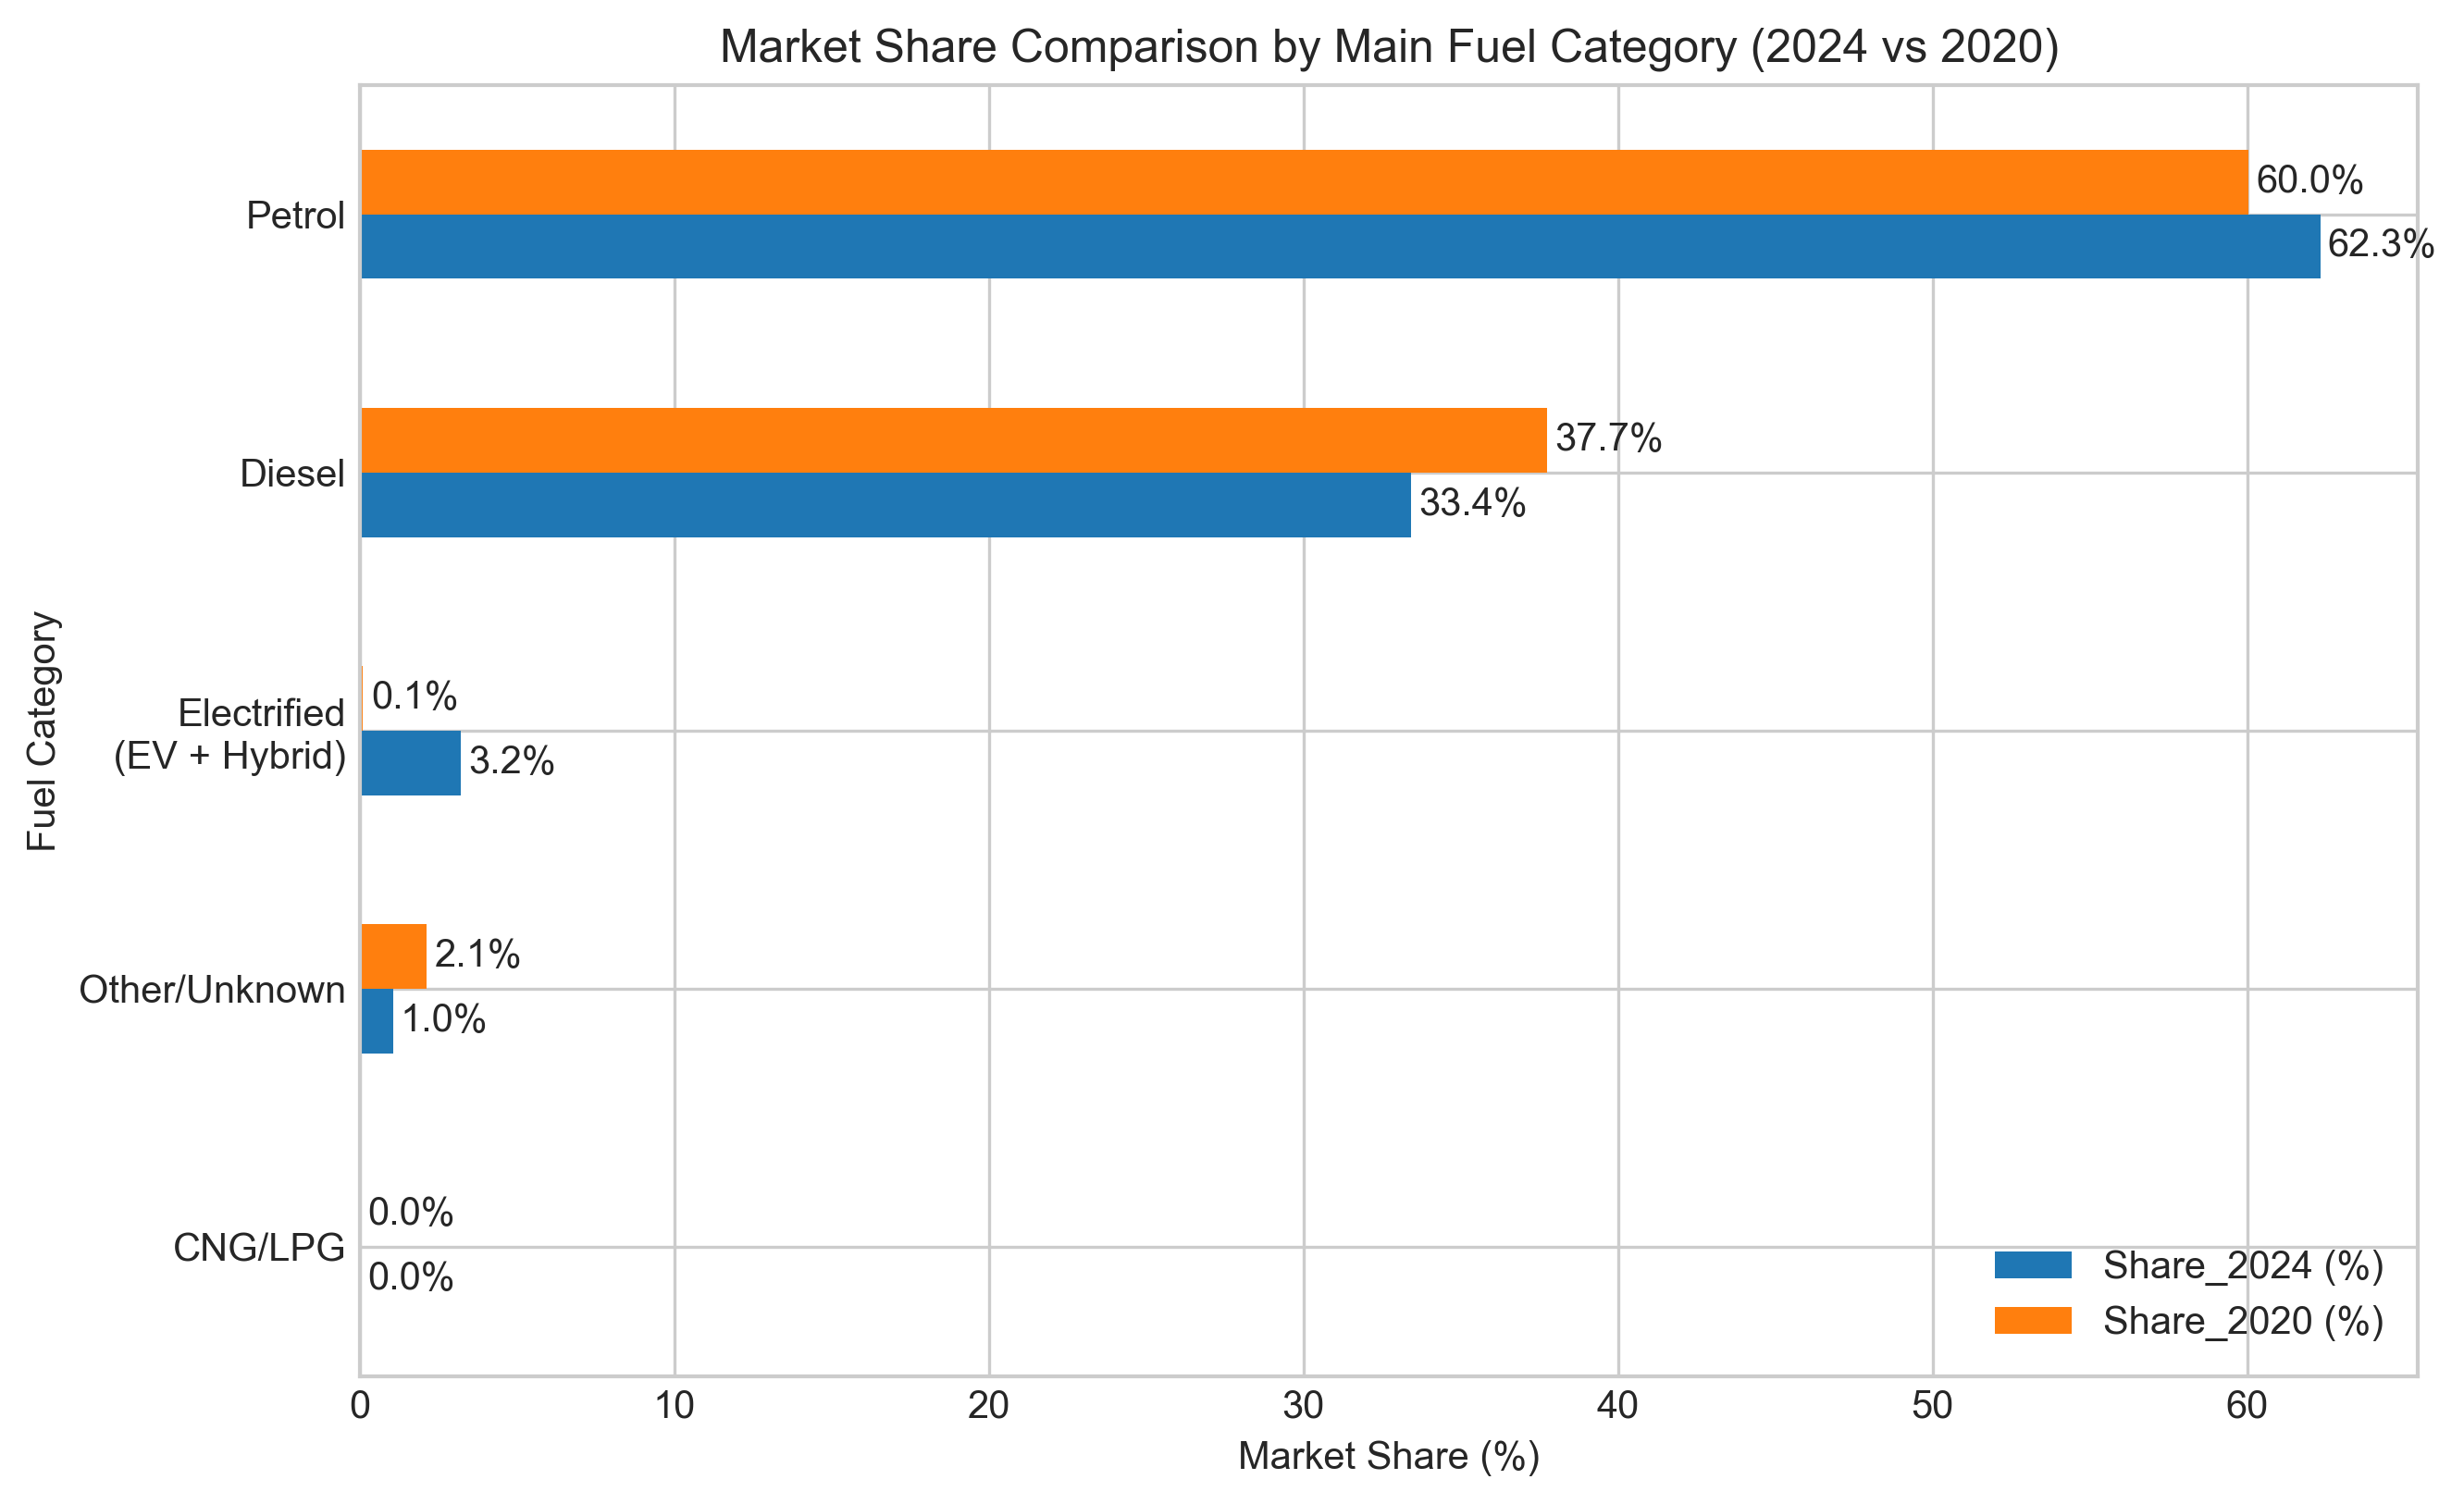

In [28]:
plt.style.use('seaborn-v0_8-whitegrid')

latest_full_year = df[df['month']==12]['year'].max()
print(f"\nComparing Market Share for Year: {latest_full_year} vs 2020 (with Combined Electrified)")

# Filter yearly_share_specific for the specific years we need
share_2020_data = yearly_share_specific[yearly_share_specific.index.year == 2020]
share_latest_data = yearly_share_specific[yearly_share_specific.index.year == latest_full_year]

if share_2020_data.empty or share_latest_data.empty:
    print(f"Error: Data for 2020 or {latest_full_year} not found.")
else:
    # Aggregate the data for each year (in case there are multiple dates per year)
    share_2020_combined = share_2020_data.mean()
    share_latest_combined = share_latest_data.mean()

    comparison_df_combined = pd.DataFrame({
        'Share_2020 (%)': share_2020_combined,
        f'Share_{latest_full_year} (%)': share_latest_combined
    })
    comparison_df_combined['Change (pp)'] = comparison_df_combined[f'Share_{latest_full_year} (%)'] - comparison_df_combined['Share_2020 (%)']
    comparison_df_combined.rename(index={'Electrified (EV + Hybrid)': 'Electrified\n (EV + Hybrid)'}, inplace=True)
    # print(comparison_df_combined.index)
    # Ensure correct columns are present before sorting
    required_cols = ['Petrol', 'Diesel', 'Electrified\n (EV + Hybrid)', 'Other/Unknown', 'CNG/LPG']
    comparison_df_combined = comparison_df_combined.reindex(required_cols, fill_value=0) # Reindex to ensure all categories exist

    comparison_df_combined = comparison_df_combined.sort_values(f'Share_{latest_full_year} (%)', ascending=False)

    print(f"\n--- Market Share Comparison: {latest_full_year} vs 2020 (Combined Electrified View) ---")
    print(comparison_df_combined.round(2))

    # --- Plotting Market Share Comparison (Combined View) ---
    comparison_df_plot_combined = comparison_df_combined[[f'Share_{latest_full_year} (%)', 'Share_2020 (%)']].sort_values(f'Share_{latest_full_year} (%)')
    
    fig, ax_combined = plt.subplots(figsize=(9, 6), dpi=300)
    comparison_df_plot_combined.plot(kind='barh', ax=ax_combined)
    
    ax_combined.set_title(f'Market Share Comparison by Main Fuel Category ({latest_full_year} vs 2020)')
    ax_combined.set_xlabel('Market Share (%)')
    ax_combined.set_ylabel('Fuel Category')
    ax_combined.legend()
    ax_combined.grid(True)
    
    # Add labels to bars
    for container in ax_combined.containers:
        ax_combined.bar_label(container, fmt='%.1f%%', label_type='edge', padding=2)
    
    # plt.suptitle('xEV Adoption Trends in India', fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [29]:
latest_full_year

np.int64(2024)

**Analysis and Findings (Including Combined Electrified Vehicles):**

1.  **Electrified Vehicle Adoption Trend & Turning Points:**
    *   **Pre-2020:** Similar to Pure EVs, the combined Electrified (EV + Hybrid) category had negligible presence before 2020. Registrations were minimal.
    *   **The Turning Point (2020-2021):** The combined data reinforces that **2020-2021** is the critical inflection period.
        *   **Absolute Growth:** The combined Electrified registrations jumped from ~9,500 in 2019 to ~12,000 in 2020 (+25% YoY), but then saw a massive surge to over **29,000** in 2021 (**+141% YoY growth**). This acceleration continued explosively in 2022, reaching nearly **92,000** registrations (**+212% YoY growth**). The log scale plot clearly shows this dramatic take-off phase starting around 2021. Hybrid registrations started contributing noticeably from 2022 onwards.
        *   **Market Share Growth:** The combined Electrified market share crossed 0.2% in 2020, surged to over 0.75% in 2021, and significantly jumped to nearly **2.0%** in 2022. The year-over-year *increase* in market share percentage points (`Electrified_Share_YoY_Change (pp)`) shows a marked acceleration from 2021 onwards, exceeding 1 percentage point gain per year from 2022.
    *   **Post-2021 Acceleration:** The combined growth remained very strong. 2023 saw over 170,000 Electrified registrations (crossing 3.8% market share), and 2024 reached over **212,000** registrations, achieving a significant **3.51%** combined market share.

    **Turning Point Conclusion (Combined):** The period **2020-2021** is confirmed as the key turning point for the broader *Electrified Vehicle* category in India, marking the transition from minimal presence to rapid, sustained growth, initially driven by Pure EVs and later significantly augmented by Hybrids.

2.  **Market Share Comparison (2024 vs. 2020 - Combined Electrified View):**

    | Aggregated Category        | Share_2020 (%) | Share_2024 (%) | Change (pp) |
    | :------------------------- | -------------: | -------------: | ----------: |
    | Petrol                     | 64.14          | 63.33          | -0.81       |
    | Diesel                     | 33.39          | 29.57          | -3.82       |
    | **Electrified (EV + Hybrid)** | **0.13**       | **3.51**       | **+3.38**   |
    | Other/Unknown              | 2.31           | 1.19           | -1.12       |
    | CNG/LPG                    | 0.02           | 0.01           | -0.01       |

    *   **Electrified (EV + Hybrid):** This combined category saw the most significant *positive* change, growing its market share dramatically from **0.13%** in 2020 to **3.51%** in 2024 (a gain of +3.38 percentage points). This highlights the growing importance of both Pure EVs and Hybrids in the market shift.
    *   **Diesel:** Experienced the largest decline in market share (-3.82 pp).
    *   **Petrol:** Showed a relatively small decrease in its overall share (-0.81 pp) based on the specified aggregation.
    *   **Other/Unknown:** Declined by -1.12 pp.
    *   **CNG/LPG (Standalone):** Remained negligible.

**Overall Conclusion:** The analysis confirms that the Indian auto market is undergoing a significant transition. While Petrol remains dominant (especially when including its variants), Diesel is steadily losing ground. The most striking trend since 2020 is the rapid emergence and growth of Electrified Vehicles (both Pure EV and Hybrid), which collectively captured over 3.5% of the market by the end of 2024, starting from almost zero in 2020. The period 2020-2021 stands out as the crucial turning point when this electrification trend truly began to accelerate.

<hr>
Okay, let's analyze the potential drivers behind the significant uptick in electrified vehicle (EV and Hybrid) adoption in India, particularly focusing on the turning point observed around 2020-2021, as clearly shown in the provided graphs.

The graphs illustrate a dramatic shift:
1.  **Absolute Registrations:** Electrified vehicle registrations were minimal for years, hovering in the low hundreds or low thousands annually. Starting in 2020, and accelerating sharply in 2021 and 2022, the numbers climbed exponentially, reaching over 212,000 in 2024.
2.  **Market Share:** The combined market share for EVs and Hybrids was negligible (<0.2%) until 2020. It then began a steep climb, crossing 0.75% in 2021, nearly 2% in 2022, and reaching approximately 3.51% by the end of 2024.

This pronounced shift suggests that a confluence of factors, rather than a single event, created a favorable environment for EV and Hybrid adoption around 2020-2021. Here’s an analysis of the likely key contributors:

1.  **Government Policy Push (Central & State Level):**
    *   **FAME II Scheme:** While launched in April 2019, the Faster Adoption and Manufacturing of Hybrid and Electric Vehicles (FAME) India Scheme Phase II gained momentum and underwent crucial amendments. Notably, in June 2021, the government significantly increased the demand incentive for electric two-wheelers and extended the scheme, signaling strong, continued support. While the provided data likely focuses on four-wheelers, the overall policy direction boosted sentiment across the EV sector.
    *   **State-Level EV Policies:** This was arguably a *major catalyst*. Starting around 2020 and intensifying in 2021, numerous states (like Delhi, Maharashtra, Gujarat, Tamil Nadu, etc.) launched their dedicated EV policies. These often included substantial incentives *beyond* FAME II, such as waivers on road tax and registration fees, and direct purchase subsidies, significantly reducing the effective ownership cost for consumers. This coincided directly with the observed surge.
    *   **Production Linked Incentives (PLI):** The announcement and subsequent implementation of PLI schemes for Advanced Chemistry Cell (ACC) battery storage and the automobile/auto components sector further encouraged manufacturers to invest in local production and development of EVs and their components.

2.  **Availability of Credible & Appealing Products:**
    *   **Major Brand Entry/Key Launches:** The period around 2020 saw the launch of more mainstream and practical EVs from established manufacturers. The **Tata Nexon EV (launched Jan 2020)** is widely considered a game-changer. It offered a popular SUV form factor, adequate range for city use, and a relatively competitive price point (though still premium), making EVs a viable option for a broader audience than before. The **MG ZS EV (also launched Jan 2020)** and the **Hyundai Kona Electric (launched mid-2019)** also contributed to providing consumers with more choices from recognized brands.
    *   **Improving Technology:** Newer models offered better battery technology, improved range, better performance, and more features compared to nascent EV offerings from previous years, addressing key consumer concerns like range anxiety.

3.  **Favourable Ownership Economics (Total Cost of Ownership - TCO):**
    *   **Rising Fossil Fuel Prices:** The period post-2020 saw significant volatility and a sharp increase in petrol and diesel prices across India. This drastically improved the TCO calculation for EVs. While the initial purchase price remained higher, the substantially lower running costs (electricity vs. petrol/diesel) and reduced maintenance needs became a much stronger selling point, especially for consumers with high mileage requirements.
    *   **Incentives Reducing Upfront Cost:** As mentioned, state and central subsidies directly lowered the high initial purchase price, making the TCO advantage accessible sooner.

4.  **Impact of the COVID-19 Pandemic:**
    *   **Initial Disruption:** The pandemic caused severe disruptions in Q1/Q2 2020, reflected in the dip in registrations across all fuel types (seen in the raw data, e.g., April 2020).
    *   **Indirect Acceleration:** While not a direct cause for *preferring* EVs, the pandemic's aftermath likely acted as an *accelerator* for factors favouring them. The sharp rise in fuel prices post-lockdowns was a significant consequence. There might also have been a subtle increase in environmental awareness and a potential shift towards personal mobility (over shared transport) where lower running costs became more critical during economic uncertainty. However, supply chain issues caused by the pandemic affected *all* vehicle manufacturing, not just EVs.

5.  **Developing Infrastructure and Awareness:**
    *   **Charging Infrastructure:** While still far from comprehensive, the visibility and deployment rate of public and semi-public charging stations started improving, helping to alleviate range anxiety, particularly in urban areas.
    *   **Consumer Awareness:** Increased media coverage, government campaigns, and the presence of new models on the road heightened consumer awareness and acceptance of EVs as a viable alternative.

**Conclusion:**

The surge in electrified vehicle adoption in India around 2020-2021 wasn't sudden in terms of underlying trends but represented a critical **inflection point** where multiple factors aligned synergistically:

*   **Proactive government policies**, especially aggressive state-level incentives, significantly lowered the cost barrier.
*   The arrival of **desirable and practical EV models** from major manufacturers provided credible alternatives to traditional vehicles.
*   **Sharply rising fossil fuel prices** made the lower running costs of EVs economically compelling for a growing number of consumers.
*   Gradual improvements in **charging infrastructure and increasing consumer awareness** supported the trend.

While COVID-19 caused initial disruption, its main contribution to the EV surge was likely indirect, primarily through its impact on fuel price economics. The combination of policy support, better products, and favourable TCO appears to be the core engine driving the adoption trends clearly visible in the data.

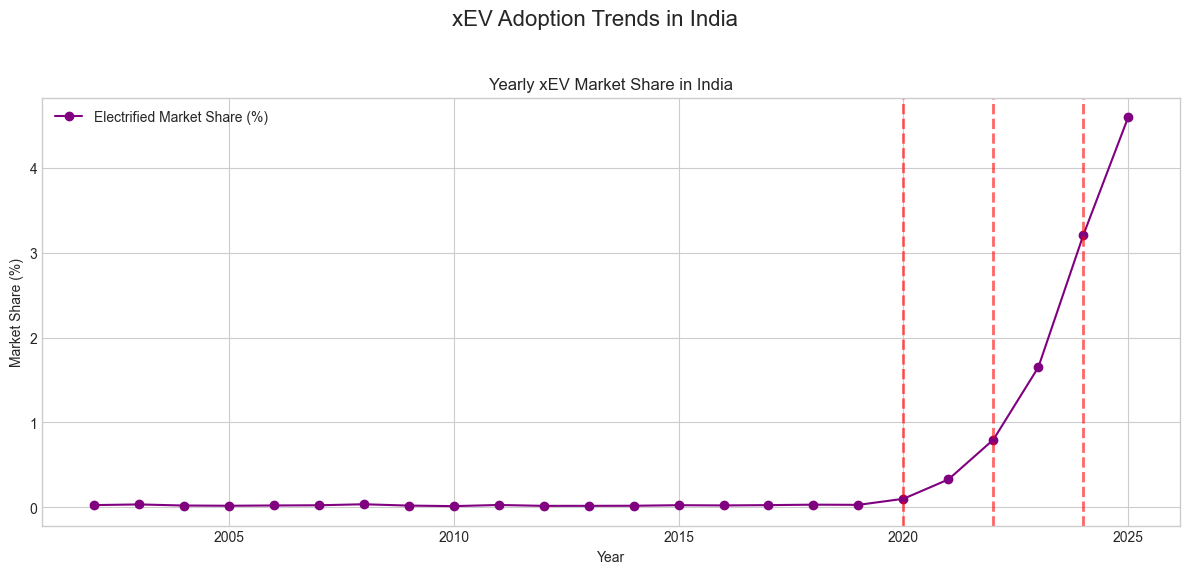

In [30]:
plt.style.use('seaborn-v0_8-whitegrid')

# Aggregate data to yearly totals
yearly_share_aggregated = yearly_share_specific.groupby(yearly_share_specific.index.year).mean()

fig_combined, axes_combined = plt.subplots(figsize=(12, 6), sharex=True)

# Plot 2: Electrified Market Share Percentage
axes_combined.plot(yearly_share_aggregated.index, yearly_share_aggregated['Electrified (EV + Hybrid)'], marker='o', linestyle='-', color='purple', label='Electrified Market Share (%)')
axes_combined.set_xlabel('Year')
axes_combined.set_ylabel('Market Share (%)')
axes_combined.set_title('Yearly xEV Market Share in India')
axes_combined.legend()
axes_combined.grid(True)

# Highlight potential turning point years visually
turning_points_years = [2020, 2022, 2024]
for year in turning_points_years:
    if year in yearly_share_aggregated.index:
        axes_combined.axvline(x=year, color='red', linestyle='--', alpha=0.6, linewidth=2)

plt.suptitle('xEV Adoption Trends in India', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()